In [20]:
import openeo, numpy as np, pandas as pd

In [21]:
# Setup backend connection (used by all downstream processing blocks)
CONNECTION = openeo.connect("openeofed.dataspace.copernicus.eu")

# List collections available on the openEO back-end
CONNECTION.list_collection_ids()

# Get detailed metadata of a certain collection
CONNECTION.describe_collection("SENTINEL2_L2A")

# authentication

CONNECTION.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeofed.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

## Sentinel-2 monthly cloud-masked composite with polygons

The next cells create a monthly Sentinel-2 RGB composite, mask cloudy pixels using the Sentinel-2 Scene Classification Layer, resample the result to a notebook-friendly output size, and draw the selected polygons on top. The polygon color is passed as a parameter.

In [22]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt


def find_repo_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "project" / "domain" / "regions.py").exists():
            return path
    raise FileNotFoundError("Could not find project/domain/regions.py")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from project.domain.regions import BAKOOL_POLYGON, BURHAKABA_POLYGON, GEDO_POLYGON


def normalize_polygon(polygon):
    points = [(float(lon), float(lat)) for lon, lat in polygon]
    if points[0] != points[-1]:
        points.append(points[0])
    return points


def buffered_extent_for_polygons(polygons, buffer_fraction=0.10):
    points = [point for polygon in polygons for point in normalize_polygon(polygon)]
    lons = [lon for lon, _ in points]
    lats = [lat for _, lat in points]

    west, east = min(lons), max(lons)
    south, north = min(lats), max(lats)
    lon_buffer = (east - west) * buffer_fraction
    lat_buffer = (north - south) * buffer_fraction

    return {
        "west": west - lon_buffer,
        "east": east + lon_buffer,
        "south": south - lat_buffer,
        "north": north + lat_buffer,
        "crs": 4326,
    }


In [23]:
def month_temporal_extent(year, month):
    if month == 12:
        return [f"{year}-12-01", f"{year + 1}-01-01"]
    return [f"{year}-{month:02d}-01", f"{year}-{month + 1:02d}-01"]


def sentinel2_monthly_rgb_cube(
    connection,
    polygons,
    year,
    month,
    max_cloud_cover=80,
    buffer_fraction=0.10,
    target_resolution_degrees=0.005,
):
    extent = buffered_extent_for_polygons(polygons, buffer_fraction=buffer_fraction)
    temporal_extent = month_temporal_extent(year, month)
    rgb_cube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=extent,
        temporal_extent=temporal_extent,
        bands=["B02", "B03", "B04"],
        properties={"eo:cloud_cover": lambda cloud_cover: cloud_cover <= max_cloud_cover},
    )
    scl_cube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=extent,
        temporal_extent=temporal_extent,
        bands=["SCL"],
        properties={"eo:cloud_cover": lambda cloud_cover: cloud_cover <= max_cloud_cover},
    )

    scl = scl_cube.band("SCL")
    cloud_or_invalid = (scl == 0) | (scl == 1) | (scl == 3) | (scl == 8) | (scl == 9) | (scl == 10) | (scl == 11)
    cloud_or_invalid = cloud_or_invalid.resample_cube_spatial(rgb_cube)
    rgb = rgb_cube.filter_bands(["B04", "B03", "B02"]).mask(cloud_or_invalid)
    rgb = rgb.rename_labels(dimension="bands", target=["red", "green", "blue"])

    monthly_mean = rgb.reduce_dimension(dimension="t", reducer="mean")
    monthly_mean = monthly_mean.resample_spatial(
        resolution=target_resolution_degrees,
        projection=4326,
        method="bilinear",
    )
    png_ready = monthly_mean.linear_scale_range(0, 3000, 0, 255)
    return png_ready, extent


def download_sentinel2_monthly_png(
    connection,
    polygons,
    year,
    month,
    output_dir=REPO_ROOT / "project" / "data" / "sentinel2",
    max_cloud_cover=80,
    buffer_fraction=0.10,
    target_resolution_degrees=0.005,
    overwrite=False,
    max_poll_interval=30,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    raw_png = output_dir / f"sentinel2_monthly_rgb_{year}_{month:02d}.png"

    cube, extent = sentinel2_monthly_rgb_cube(
        connection=connection,
        polygons=polygons,
        year=year,
        month=month,
        max_cloud_cover=max_cloud_cover,
        buffer_fraction=buffer_fraction,
        target_resolution_degrees=target_resolution_degrees,
    )
    if overwrite or not raw_png.exists():
        print("Starting openEO batch job. This can take a few minutes.")
        cube.execute_batch(
            outputfile=raw_png,
            out_format="PNG",
            title=f"Sentinel-2 monthly RGB {year}-{month:02d}",
            max_poll_interval=max_poll_interval,
        )

    return raw_png, extent


In [24]:
def draw_polygons_on_sentinel2_png(
    image_path,
    extent,
    polygons,
    polygon_color="yellow",
    output_path=None,
    linewidth=2.5,
    figsize=(10, 10),
):
    image_path = Path(image_path)
    if output_path is None:
        output_path = image_path.with_name(f"{image_path.stem}_polygons.png")
    output_path = Path(output_path)

    image = plt.imread(image_path)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(
        image,
        extent=[extent["west"], extent["east"], extent["south"], extent["north"]],
        origin="upper",
    )

    for polygon in polygons:
        points = normalize_polygon(polygon)
        xs = [lon for lon, _ in points]
        ys = [lat for _, lat in points]
        ax.plot(xs, ys, color=polygon_color, linewidth=linewidth)

    ax.set_xlim(extent["west"], extent["east"])
    ax.set_ylim(extent["south"], extent["north"])
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Sentinel-2 monthly RGB composite: {image_path.stem}")
    ax.grid(color="white", alpha=0.25, linewidth=0.7)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180)
    plt.show()
    return output_path


## Minimal Sentinel-2 proof of concept

This tiny version uses one small polygon, a coarse output resolution, no cloud mask, and only one week of data. Use this first to verify that openEO can produce a satellite image quickly.

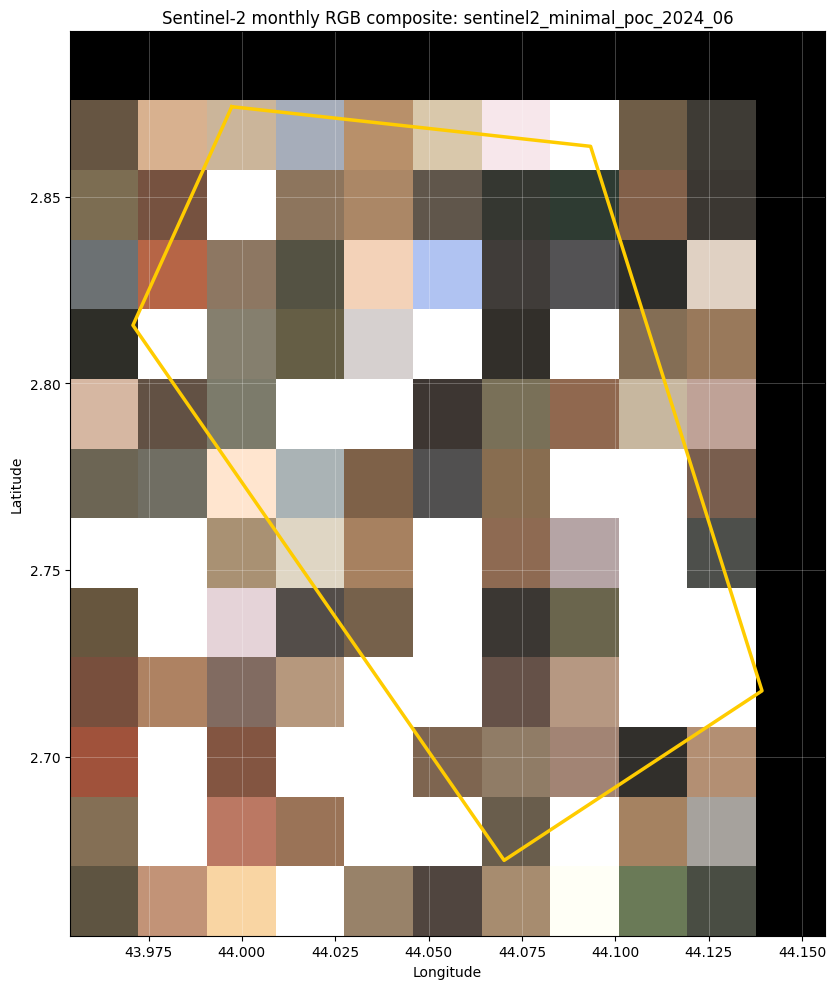

PosixPath('/home/jjonkhans/HACKATHONS/ZERO_ONE_HACK/project/data/sentinel2/sentinel2_minimal_poc_2024_06_polygons.png')

In [25]:
def sentinel2_minimal_poc_png(
    connection,
    polygon=BAKOOL_POLYGON,
    year=2024,
    month=6,
    day_window=7,
    polygon_color="#ffcc00",
    target_resolution_degrees=0.02,
    max_cloud_cover=100,
    output_dir=REPO_ROOT / "project" / "data" / "sentinel2",
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    extent = buffered_extent_for_polygons([polygon], buffer_fraction=0.10)
    raw_png = output_dir / f"sentinel2_minimal_poc_{year}_{month:02d}.png"

    cube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=extent,
        temporal_extent=[f"{year}-{month:02d}-01", f"{year}-{month:02d}-{day_window + 1:02d}"],
        bands=["B04", "B03", "B02"],
        properties={"eo:cloud_cover": lambda cloud_cover: cloud_cover <= max_cloud_cover},
    )
    rgb = cube.reduce_dimension(dimension="t", reducer="mean")
    rgb = rgb.resample_spatial(
        resolution=target_resolution_degrees,
        projection=4326,
        method="bilinear",
    )
    rgb = rgb.rename_labels(dimension="bands", target=["red", "green", "blue"])
    rgb = rgb.linear_scale_range(0, 3000, 0, 255)

    print(f"Downloading tiny POC to {raw_png}")
    rgb.download(str(raw_png), format="PNG")

    overlay_png = draw_polygons_on_sentinel2_png(
        image_path=raw_png,
        extent=extent,
        polygons=[polygon],
        polygon_color=polygon_color,
    )
    return raw_png, overlay_png


raw_png, overlay_png = sentinel2_minimal_poc_png(CONNECTION)
overlay_png


In [ ]:
# Heavier cloud-masked version. Run the minimal POC above first.
# Parameters
POLYGONS = [BAKOOL_POLYGON]
YEAR = 2024
MONTH = 6
POLYGON_COLOR = "#ffcc00"
MAX_CLOUD_COVER = 80
TARGET_RESOLUTION_DEGREES = 0.02  # coarse POC resolution; lower values create much larger jobs

raw_png, sentinel_extent = download_sentinel2_monthly_png(
    connection=CONNECTION,
    polygons=POLYGONS,
    year=YEAR,
    month=MONTH,
    max_cloud_cover=MAX_CLOUD_COVER,
    target_resolution_degrees=TARGET_RESOLUTION_DEGREES,
)

overlay_png = draw_polygons_on_sentinel2_png(
    image_path=raw_png,
    extent=sentinel_extent,
    polygons=POLYGONS,
    polygon_color=POLYGON_COLOR,
)

overlay_png


Starting openEO batch job. This can take a few minutes.
0:00:00 Job 'cdse-j-2605310050354f27853c7cc58f3fce04': send 'start'
0:00:08 Job 'cdse-j-2605310050354f27853c7cc58f3fce04': queued (progress 0%)
0:00:14 Job 'cdse-j-2605310050354f27853c7cc58f3fce04': queued (progress 0%)
0:00:21 Job 'cdse-j-2605310050354f27853c7cc58f3fce04': queued (progress 0%)
0:00:29 Job 'cdse-j-2605310050354f27853c7cc58f3fce04': queued (progress 0%)
0:00:39 Job 'cdse-j-2605310050354f27853c7cc58f3fce04': queued (progress 0%)
0:00:52 Job 'cdse-j-2605310050354f27853c7cc58f3fce04': queued (progress 0%)
0:01:07 Job 'cdse-j-2605310050354f27853c7cc58f3fce04': running (progress N/A)
0:01:26 Job 'cdse-j-2605310050354f27853c7cc58f3fce04': running (progress N/A)
0:01:51 Job 'cdse-j-2605310050354f27853c7cc58f3fce04': running (progress N/A)
0:02:21 Job 'cdse-j-2605310050354f27853c7cc58f3fce04': running (progress N/A)
0:02:51 Job 'cdse-j-2605310050354f27853c7cc58f3fce04': running (progress N/A)
0:03:21 Job 'cdse-j-2605310050